Анализ и генерация признаков (WoE/IV)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем стиль графиков
sns.set_theme(style="whitegrid")

# Загружаем данные, созданные на Этапе 1
df = pd.read_csv('../data/bank_loan_data.csv')
print(f"Размерность данных: {df.shape}")
df.head()


Размерность данных: (10000, 9)


,client_id,age,monthly_income,credit_limit,utilization_rate,delinquencies_30_plus,loan_amount,interest_rate,is_default
0,1,59,46102,36299,0.35,1,30516,0.16,0
1,2,49,44003,31318,0.21,0,25240,0.16,0
2,3,35,45004,117104,0.34,0,96376,0.16,1
3,4,63,122408,191879,0.10,0,154979,0.16,0
4,5,28,28357,46176,0.67,1,30112,0.16,1


/var/folders/gl/_fhvd07j6_n7sw_nnq7v16bc0000gn/T/ipykernel_2894/3418724371.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_default', data=df, ax=ax[0], palette='viridis')
/var/folders/gl/_fhvd07j6_n7sw_nnq7v16bc0000gn/T/ipykernel_2894/3418724371.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Вернули (0)', 'Дефолт (1)'])


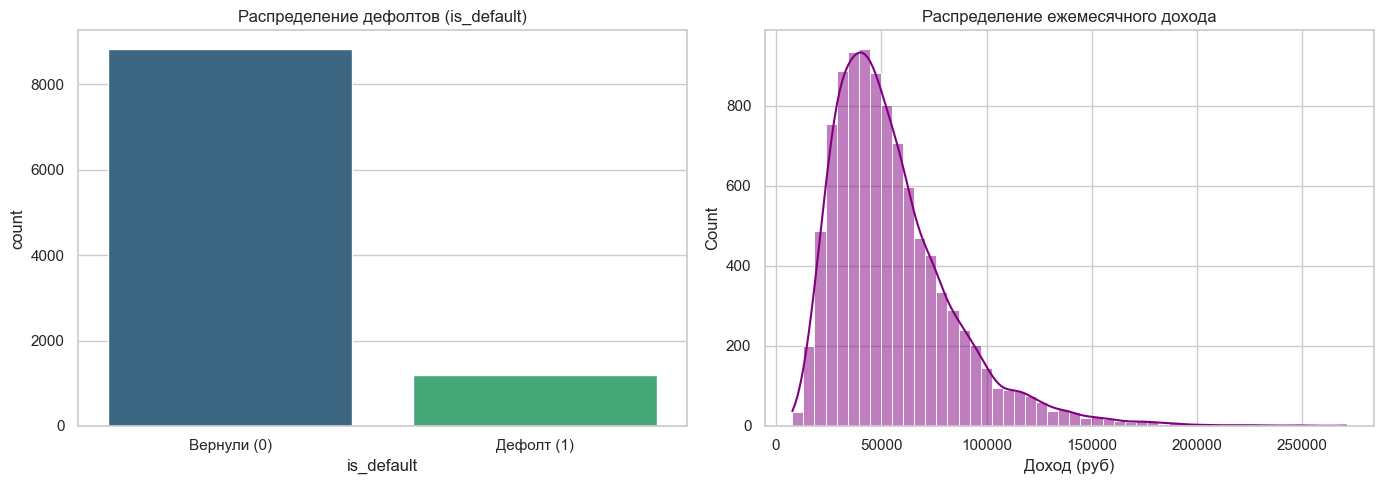

Доля дефолтных клиентов в портфеле: 11.82%


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# График баланса классов
sns.countplot(x='is_default', data=df, ax=ax[0], palette='viridis')
ax[0].set_title('Распределение дефолтов (is_default)')
ax[0].set_xticklabels(['Вернули (0)', 'Дефолт (1)'])

# Логарифмическое распределение доходов
sns.histplot(df['monthly_income'], kde=True, ax=ax[1], color='purple', bins=50)
ax[1].set_title('Распределение ежемесячного дохода')
ax[1].set_xlabel('Доход (руб)')

plt.tight_layout()
plt.show()

print(f"Доля дефолтных клиентов в портфеле: {df['is_default'].mean():.2%}")


In [20]:
def calculate_woe_iv(dataset, feature, target):
    # Для непрерывных признаков делаем квантильное разбиение на 5 бакетов
    if dataset[feature].nunique() > 10:
        df_bucket = dataset.copy()
        df_bucket[feature] = pd.qcut(dataset[feature], q=5, duplicates='drop').astype(str)
    else:
        df_bucket = dataset.copy()
        df_bucket[feature] = dataset[feature].astype(str)
        
    # Считаем количество хороших (0) и плохих (1) заемщиков
    grouped = df_bucket.groupby(feature)[target].agg(['count', 'sum'])
    grouped.columns = ['Total', 'Bad']
    grouped['Good'] = grouped['Total'] - grouped['Bad']
    
    # Доли от общего количества
    total_good = grouped['Good'].sum()
    total_bad = grouped['Bad'].sum()
    
    grouped['Good_Dist'] = grouped['Good'] / total_good
    grouped['Bad_Dist'] = grouped['Bad'] / total_bad
    
    # Расчет WoE и IV (добавляем крошечное число во избежание деления на 0)
    grouped['WoE'] = np.log((grouped['Good_Dist'] + 1e-6) / (grouped['Bad_Dist'] + 1e-6))
    grouped['IV'] = (grouped['Good_Dist'] - grouped['Bad_Dist']) * grouped['WoE']
    
    total_iv = grouped['IV'].sum()
    
    return grouped[['Total', 'Good', 'Bad', 'WoE', 'IV']], total_iv


/var/folders/gl/_fhvd07j6_n7sw_nnq7v16bc0000gn/T/ipykernel_2894/2951640388.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IV', y='Feature', data=iv_df, palette='magma')


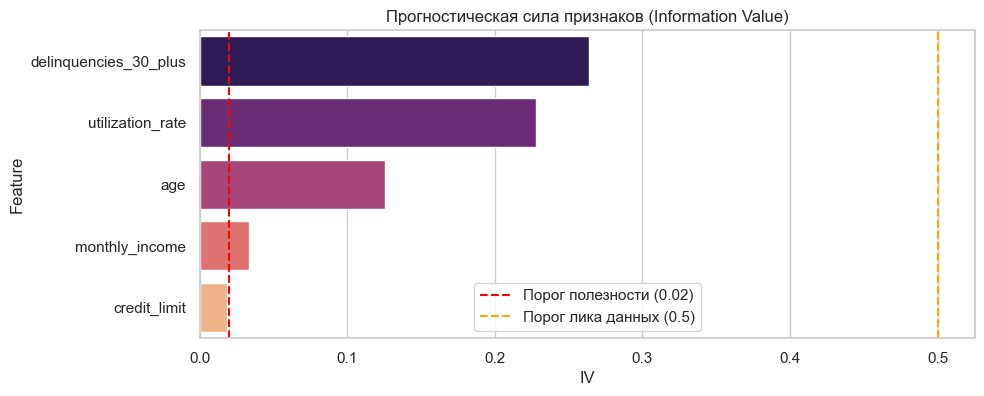

,Feature,IV
4,delinquencies_30_plus,0.263779
3,utilization_rate,0.227611
0,age,0.125538
1,monthly_income,0.033700
2,credit_limit,0.018475


In [21]:
features = ['age', 'monthly_income', 'credit_limit', 'utilization_rate', 'delinquencies_30_plus']
iv_dict = {}

for f in features:
    _, iv = calculate_woe_iv(df, f, 'is_default')
    iv_dict[f] = iv

iv_df = pd.DataFrame(list(iv_dict.items()), columns=['Feature', 'IV']).sort_values(by='IV', ascending=False)

# Визуализация IV
plt.figure(figsize=(10, 4))
sns.barplot(x='IV', y='Feature', data=iv_df, palette='magma')
plt.axvline(x=0.02, color='red', linestyle='--', label='Порог полезности (0.02)')
plt.axvline(x=0.5, color='orange', linestyle='--', label='Порог лика данных (0.5)')
plt.title('Прогностическая сила признаков (Information Value)')
plt.legend()
plt.show()

iv_df


In [22]:
# Фиксируем финальный набор колонок для моделирования 

df.to_csv('../data/bank_loan_data_features.csv', index=False)
print("Данные для этапа моделирования успешно сохранены!")


Данные для этапа моделирования успешно сохранены!
